<div style="background: linear-gradient(90deg, #2c3e50, #3498db); 
            padding: 20px; border-radius: 10px; text-align:center;">
    <h1 style="color:white; font-family:Trebuchet MS, sans-serif; font-size:40px;">
        📊 Machine Learning Analysis 🚀
    </h1>
    <p style="color:#ecf0f1; font-size:18px; margin-top:10px; text-align:center">
        K-Nearest Neighbour Algo
    </p>
</div>


In [64]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [65]:
df = pd.read_csv("500hits.csv", encoding='latin1')

In [66]:
df.head(7).style.background_gradient(cmap="Set2")

,PLAYER,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA,HOF
0,Ty Cobb,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,178,0.366000,1
1,Stan Musial,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,31,0.331000,1
2,Tris Speaker,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,129,0.345000,1
3,Derek Jeter,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,97,0.310000,1
4,Honus Wagner,21,2792,10430,1736,3430,640,252,101,0,963,327,722,15,0.329000,1
5,Carl Yastrzemski,23,3308,11988,1816,3419,646,59,452,1844,1845,1393,168,116,0.285000,1
6,Paul Molitor,21,2683,10835,1782,3319,605,114,234,1307,1094,1244,504,131,0.306000,1


In [67]:
df = df.drop(columns=["PLAYER", "CS"])

In [68]:
df.head().style.background_gradient(cmap="Set2")

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,BA,HOF
0,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,0.366000,1
1,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,0.331000,1
2,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,0.345000,1
3,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,0.310000,1
4,21,2792,10430,1736,3430,640,252,101,0,963,327,722,0.329000,1


In [69]:
X = df.iloc[:, 0:13]   # features

In [70]:
y = df.iloc[:, 13]   

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(372, 13) (372,) (93, 13) (93,)


In [74]:
from sklearn.tree import DecisionTreeClassifier # assign it to the variable "dtc"

In [75]:
dtc = DecisionTreeClassifier()

In [76]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [77]:
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
y_pred = dtc.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [80]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        60
           1       0.77      0.73      0.75        33

    accuracy                           0.83        93
   macro avg       0.81      0.81      0.81        93
weighted avg       0.83      0.83      0.83        93



In [81]:
print(confusion_matrix(y_pred,y_test))

[[53  7]
 [ 9 24]]


In [82]:
features = pd.DataFrame(dtc.feature_importances_, index = X.columns)

In [83]:
features.style.background_gradient(cmap="coolwarm")

,0
YRS,0.016550
G,0.033193
AB,0.023723
R,0.305579
H,0.077973
2B,0.024068
3B,0.048191
HR,0.071688
RBI,0.101063
BB,0.037184


In [92]:
dtc2 = DecisionTreeClassifier(criterion='entropy', ccp_alpha= 0.04)

In [93]:
dtc2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.04
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.

In [94]:
y_pred2 = dtc2.predict(X_test)

In [95]:
print(confusion_matrix(y_test, y_pred2))

[[55  7]
 [11 20]]


In [96]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        62
           1       0.74      0.65      0.69        31

    accuracy                           0.81        93
   macro avg       0.79      0.77      0.77        93
weighted avg       0.80      0.81      0.80        93



In [97]:
features2 = pd.DataFrame(dtc2.feature_importances_, index = X.columns)

In [98]:
features2.style.background_gradient(cmap="coolwarm")

,0
YRS,0.000000
G,0.000000
AB,0.000000
R,0.553898
H,0.000000
2B,0.000000
3B,0.000000
HR,0.000000
RBI,0.148129
BB,0.000000


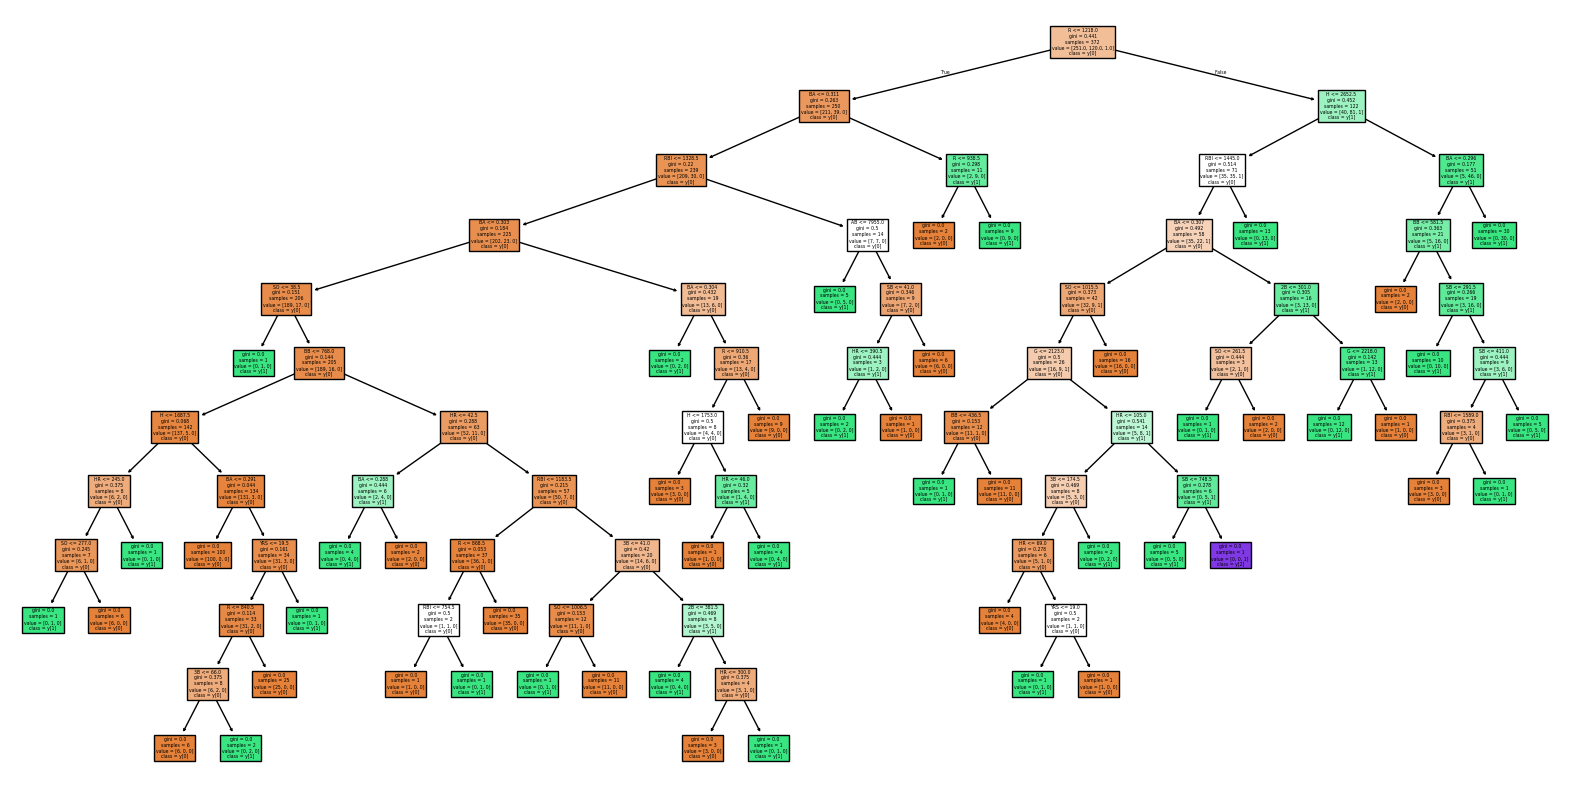

In [99]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dtc, filled=True, feature_names=X.columns, class_names=True)
plt.show()

<div style="background-color:#f9f9f9; border-top:6px solid #3498db; 
            padding:20px; border-radius:8px; text-align:center; margin-top:40px;">
    <h2 style="color:#2c3e50; font-family:Arial, sans-serif;">
        ✅ End of Notebook
    </h2>
    <p style="font-size:16px; color:#34495e; text-align:center">
        Thank you for reviewing this analysis.<br>
        🚀 Keep experimenting, keep learning!
    </p>
</div>